# Notebook support pour projet ML modèle supervisé
## NoteBook 1 - Contexte général, Analyse exploratoire des données et Feature engineering

### Contexte général :

<u>Contexte et objectif:</u>
Des relevés minutieux ont été effectués par les agents de la ville de Seattle en 2016 qui ont été rassemblés dans le fichier '2016_Building_Energy_Benchmarking.csv'. 
Ces relevés sont coûteux à obtenir, et à partir de ceux déjà réalisés, nous voulons tenter de prédire les émissions de CO2 et la consommation totale d’énergie de bâtiments non destinés à l’habitation pour lesquels elles n’ont pas encore été mesurées.

<u>**La démarche pour y parvenir suivra les étapes suivantes :**</u>

0. Configurer notre environnement de travail,  

    *Création de l’environnement virtuel*  
    *Dans le dossier racine du projet, exécutez : `uv venv`*  
    *Installer les dépendances*   
    *Toujours dans le dossier racine du projet, exécutez : `uv sync` pour plus d'informations sur les dépendances voir Pyproject.toml (résumé) ou uv.lock (détaillé)*

1. Réaliser une analyse Exploratoire des données,
2. Nettoyer notre jeu de données, 
3. Choix des feature utiles pour notre modélisation,
4. Réalisation d'un feature engineering, 
5. Encodage des variables catégorielles,
6. Teste de plusieurs modèles et analyse des performances, 
7. Choix du meilleur modèle, optimisation et interprétation,
8. Formaliser nos résultats

# Notebook 1 - Analyse exploratoire, nettoyage et feature engineering

## Objectif du notebook

Ce notebook a pour rôle de préparer le jeu de données avant la modélisation :
- comprendre la structure du dataset brut ;
- filtrer les observations non exploitables ;
- définir les variables cibles ;
- contrôler la qualité des données ;
- créer des variables explicatives plus informatives ;
- exporter un dataset final propre pour la modélisation.

## Démarche suivie

### 1. Chargement et compréhension du dataset brut
- [x] Chargement du fichier source `2016_Building_Energy_Benchmarking.csv`
- [x] Contrôle de la structure générale (`shape`, types, taux de valeurs nulles)
- [x] Repérage des variables peu utiles, très manquantes ou non pertinentes pour la modélisation

### 2. Filtrage métier et nettoyage
- [x] Exclusion des bâtiments résidentiels (focus sur les bâtiments tertiaires)
- [x] Suppression des lignes `DefaultData = True`
- [x] Suppression des lignes marquées comme outliers métier
- [x] Suppression des lignes avec valeurs impossibles ou incohérentes sur les cibles
- [x] Traitement des valeurs manquantes sur les variables clés
- [x] Remplacement de certains zéros non exploitables (`NumberofFloors`, `NumberofBuildings`) par une valeur minimale cohérente

### 3. Définition des cibles
- [x] Construction de `EnergyTarget`
- [x] Construction de `CO2Target`
- [x] Vérification de la distribution des deux cibles
- [x] Contrôle des valeurs faibles, nulles et extrêmes

### 4. Analyse exploratoire
- [x] Analyse univariée des variables numériques
- [x] Analyse des distributions catégorielles
- [x] Analyse de corrélation avec les cibles
- [x] Vérification du skew des variables
- [x] Identification de la forte asymétrie des deux cibles

### 5. Feature engineering
- [x] Création de variables physiques (âge du bâtiment, ratios de surface, ratios parking)
- [x] Création de variables d’usage (ratios d’usage principal / secondaire / tertiaire, nombre d’usages)
- [x] Création de variables énergie (sources utilisées, source principale, nombre de sources)
- [x] Création de variables de structure (catégories d’âge, catégories de taille)
- [x] Conservation de l’information de missingness pour `ENERGYSTARScore`

### 6. Sélection finale des variables
- [x] Suppression de variables redondantes
- [x] Constitution du DataFrame final pour la modélisation
- [x] Export final dans `df_modele.csv`

## Hypothèses et choix méthodologiques

- Les bâtiments résidentiels sont exclus pour conserver un périmètre homogène de prédiction.
- Les lignes `DefaultData` et certains cas aberrants sont retirés car jugés trop peu fiables.
- Les très fortes asymétries des variables sont acceptées comme caractéristiques naturelles du problème.
- `ENERGYSTARScore` est conservé comme variable optionnelle pour tester son apport réel en modélisation.
- Certaines variables dérivées de l’énergie observée sont conservées, en considérant qu’elles peuvent être utiles selon le cadre de prédiction retenu.

## Résultat attendu en sortie du notebook

- [x] Un dataset final propre, structuré et exploitable : `df_modele.csv`
- [x] Deux variables cibles prêtes pour la modélisation : `EnergyTarget` et `CO2Target`
- [x] Un ensemble de features enrichies et mieux adaptées que les variables brutes

## Point de vigilance pour la suite

- Les deux cibles restent fortement asymétriques, ce qui peut dégrader certaines métriques comme le `MAPE`.
- Les performances futures dépendront fortement de la qualité des variables construites.
- Toute modification du filtrage ou du feature engineering implique de réexporter `df_modele.csv` avant de relancer le notebook de modélisation.

## Ouverture

La prochaine étape consiste à comparer plusieurs modèles supervisés sur les deux cibles, à sélectionner les plus pertinents selon une métrique clairement définie, puis à mesurer l’effet réel de variables clés comme `ENERGYSTARScore` sur les performances finales.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

building_consumption = pd.read_csv('2016_Building_Energy_Benchmarking.csv')
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [3]:
import importlib
import Fonctions_EDA
importlib.reload(Fonctions_EDA)

from Fonctions_EDA import eda_overview

eda_overview(building_consumption)



## 1) Vue globale

,n_lignes,n_colonnes,doublons,%_doublons
0,3376,46,0,0.0


## 2) Qualité des colonnes et cardinalité

,dtype,%null,non_null,null,n_uniques
DefaultData,bool,0.00,3376,0,2
Comments,float64,100.00,0,3376,0
ThirdLargestPropertyUseTypeGFA,float64,82.35,596,2780,501
SecondLargestPropertyUseTypeGFA,float64,50.27,1679,1697,1352
ENERGYSTARScore,float64,24.97,2533,843,100
LargestPropertyUseTypeGFA,float64,0.59,3356,20,3122
ZipCode,float64,0.47,3360,16,55
SourceEUI(kBtu/sf),float64,0.27,3367,9,1648
SourceEUIWN(kBtu/sf),float64,0.27,3367,9,1694
SteamUse(kBtu),float64,0.27,3367,9,131


## 3) Variables numériques (30)

...

,%outliers (IQR),nb_outliers_bas,nb_outliers_haut,min,Q1,median,Q3,max,skew,kurtosis
OSEBuildingID,26.60,639,259,1.00000,19990.750000,2.311200e+04,2.599425e+04,5.022600e+04,-0.008279,0.650867
PropertyGFAParking,14.93,0,504,0.00000,0.000000,0.000000e+00,0.000000e+00,5.126080e+05,6.651191,58.974892
SecondLargestPropertyUseTypeGFA,12.27,0,206,0.00000,5000.000000,1.066400e+04,2.664000e+04,6.867500e+05,5.033481,36.302083
Electricity(kBtu),11.61,0,391,-115417.00000,639487.000000,1.177583e+06,2.829632e+06,6.570744e+08,28.728464,1157.498861
Electricity(kWh),11.61,0,391,-33826.80078,187422.945350,3.451299e+05,8.293178e+05,1.925775e+08,28.728464,1157.498858
SiteEnergyUse(kBtu),11.36,0,383,0.00000,925128.593750,1.803753e+06,4.222455e+06,8.739237e+08,24.841979,858.618481
SiteEnergyUseWN(kBtu),11.31,0,381,0.00000,970182.234375,1.904452e+06,4.381429e+06,4.716139e+08,15.269067,334.505017
PropertyGFATotal,10.96,0,370,11285.00000,28487.000000,4.417500e+04,9.099200e+04,9.320156e+06,24.129407,946.239491
TotalGHGEmissions,10.90,0,367,-0.80000,9.495000,3.392000e+01,9.394000e+01,1.687098e+04,19.481875,474.892223
LargestPropertyUseTypeGFA,10.55,0,354,5656.00000,25094.750000,3.989400e+04,7.620025e+04,9.320156e+06,30.095951,1320.609838


## 4) Variables catégorielles (16)

,n_uniques,null,%null,modalite_top,nb_modalite_top
Outlier,2,3344,99.05,Low outlier,23
YearsENERGYSTARCertified,65,3257,96.48,2016,14
ThirdLargestPropertyUseType,44,2780,82.35,Retail Store,110
SecondLargestPropertyUseType,50,1697,50.27,Parking,976
LargestPropertyUseType,56,20,0.59,Multifamily Housing,1667
ListOfAllPropertyUseTypes,466,9,0.27,Multifamily Housing,866
PropertyName,3362,0,0.00,Northgate Plaza,3
Address,3354,0,0.00,2203 Airport Way S,4
TaxParcelIdentificationNumber,3268,0,0.00,1625049001,8
PrimaryPropertyType,24,0,0.00,Low-Rise Multifamily,987


## 5) Variables temporelles (0)

_Aucune variable datetime._

**Taille dataset global : 3376 L x 46 C**  
**Pas d'incoherences majeures de dtype detectees, sauf `YearsENERGYSTARCertified` en object (colonne non retenue).**  

### **Variables type bool & object :**  
`DefaultData` : pas decrite dans la doc. Les lignes `True` sont supprimees.

### **Variables numeriques avec fort taux de valeurs manquantes**  
`Comments` vide => suppression  
`ComplianceStatus` => suppression des categories non exploitables (via filtre `DefaultData=False` + nettoyage)  
`ThirdLargestPropertyUseTypeGFA` => conservee puis imputee a 0  
`SecondLargestPropertyUseTypeGFA` => conservee puis imputee a 0  
`ENERGYSTARScore` => conservee (valeur optionnelle testee ensuite en modelisation)

### **Targets retenues dans ce notebook**
- `EnergyTarget = SiteEnergyUseWN(kBtu)`
- `CO2Target = TotalGHGEmissions`



Analyse de ComplianceStatus X DefaultData

In [4]:
building_consumption["ComplianceStatus"].value_counts(dropna=False)

ComplianceStatus
Compliant                       3211
Error - Correct Default Data     113
Non-Compliant                     37
Missing Data                      15
Name: count, dtype: int64

In [5]:
building_consumption["DefaultData"].value_counts(dropna=False)

DefaultData
False    3263
True      113
Name: count, dtype: int64

In [6]:
mask_default = building_consumption["DefaultData"] == True
mask_error = building_consumption["ComplianceStatus"] == "Error - Correct Default Data"

print(mask_default.sum(), mask_error.sum())          # attendus: 113, 113
print((mask_default == mask_error).all())            # True => exactement les mêmes lignes


113 113
True


In [7]:
building_consumption["Outlier"].value_counts()

Outlier
Low outlier     23
High outlier     9
Name: count, dtype: int64

Décompte des bâtiments résidentiels et non résidentiels + sélection des bâtiments tertiaires uniquement.

In [8]:
df = building_consumption.copy()
df["BuildingType"].value_counts()


BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [9]:
df = df[~df["BuildingType"].str.contains("Multifamily", na=False)].copy()

df["BuildingType"].value_counts()

BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

In [10]:
df.shape

(1668, 46)

### TAILLE DATASET AVANT NETTOYAGE DES DONNEES :

On part donc avec un nombre de ligne égale à 1668. 

Passons aux premières suppressions identifiées sur colonne Outlier, colonne ComplianceStatus/DefaultData.  

In [11]:
print(df.columns.tolist())


['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity']


In [12]:
# 1) Filtre des lignes
df = df[(df["DefaultData"] == False) & (df["Outlier"].isna())].copy()

# 2) Suppression colonnes devenues inutiles
df.drop(columns=["Outlier", "ComplianceStatus", "DefaultData"], inplace=True)

# 3) Contrôle après suppression
print("Nb lignes après filtre :", len(df))
print("Nb colonnes :", df.shape[1])

Nb lignes après filtre : 1565
Nb colonnes : 43


In [13]:
# 1) Listes des features, target et colonnes à conserver
import numpy as np
#df["SiteEnergyUseWN(kBtu)_log"] = np.log1p(df["SiteEnergyUseWN(kBtu)"])
#df["EnergyTarget"] = df["SiteEnergyUseWN(kBtu)_log"]
df["EnergyTarget"] = df["SiteEnergyUseWN(kBtu)"]
#df["EnergyTarget"] = df["SiteEUIWN(kBtu/sf)"]
df["CO2Target"] = df["TotalGHGEmissions"] 

target_cols = [
    "EnergyTarget",     # target conso energie
    "CO2Target",    # target emissions GHGE (CO2)
    "SiteEUIWN(kBtu/sf)",
    "GHGEmissionsIntensity"
]

num_cols = [
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "ENERGYSTARScore",          
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFABuilding(s)",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "SteamUse(kBtu)",
    "Electricity(kBtu)",
    "NaturalGas(kBtu)",
    "YearBuilt"
]

cat_cols = [
    "BuildingType",
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType",
    "Neighborhood"
]


# 2) Suppression colonnes non retenues

analyse_cols = num_cols + cat_cols + target_cols
df = df[analyse_cols].copy()


# 3) Contrôle rapide
print("Nb lignes après filtre :", len(df))
print("Nb colonnes :", df.shape[1])

Nb lignes après filtre : 1565
Nb colonnes : 23


### Filtrage final et analyse avant modelisation : 

Dans cette phase :
- traitement des valeurs manquantes (suppression ou imputation selon la variable),
- suppression des valeurs impossibles,
- traitement des outliers via percentile sur variables d'intensite,
- verification finale avant analyses univariees puis bivariees.



In [15]:
eda_overview(df)

## 1) Vue globale

,n_lignes,n_colonnes,doublons,%_doublons
0,1565,23,0,0.0


## 2) Qualité des colonnes et cardinalité

,dtype,%null,non_null,null,n_uniques
ThirdLargestPropertyUseTypeGFA,float64,77.76,348,1217,300
SecondLargestPropertyUseTypeGFA,float64,46.13,843,722,694
ENERGYSTARScore,float64,36.29,997,568,100
LargestPropertyUseTypeGFA,float64,0.38,1559,6,1464
EnergyTarget,float64,0.19,1562,3,1539
SiteEUIWN(kBtu/sf),float64,0.19,1562,3,954
NumberofBuildings,float64,0.13,1563,2,16
SteamUse(kBtu),float64,0.13,1563,2,114
Electricity(kBtu),float64,0.13,1563,2,1553
NaturalGas(kBtu),float64,0.13,1563,2,1108


## 3) Variables numériques (17)

...

,%outliers (IQR),nb_outliers_bas,nb_outliers_haut,min,Q1,median,Q3,max,skew,kurtosis
PropertyGFAParking,21.09,0,330,0.00,0.000000e+00,0.000000e+00,0.000000e+00,5.126080e+05,5.054346,33.214647
SecondLargestPropertyUseTypeGFA,14.59,0,123,0.00,5.567500e+03,1.210200e+04,3.188100e+04,6.867500e+05,4.118918,22.650633
PropertyGFATotal,12.46,0,195,11285.00,2.892300e+04,4.885000e+04,1.079300e+05,9.320156e+06,18.637119,524.313285
Electricity(kBtu),11.32,0,177,-115417.00,7.257405e+05,1.705403e+06,5.169772e+06,6.570744e+08,20.323091,567.519591
NaturalGas(kBtu),11.20,0,175,0.00,0.000000e+00,4.768320e+05,1.529781e+06,2.979090e+08,21.447080,594.777252
PropertyGFABuilding(s),11.05,0,173,3636.00,2.808000e+04,4.656000e+04,9.599500e+04,9.320156e+06,21.064207,630.249315
EnergyTarget,10.95,0,171,0.00,1.293946e+06,2.788274e+06,7.426902e+06,4.716139e+08,11.012857,168.813339
CO2Target,10.81,0,169,-0.80,2.011000e+01,4.962000e+01,1.470700e+02,1.687098e+04,13.785759,232.195970
LargestPropertyUseTypeGFA,10.46,0,163,5656.00,2.519200e+04,4.275500e+04,9.221450e+04,9.320156e+06,22.648248,704.427042
ThirdLargestPropertyUseTypeGFA,10.34,0,36,0.00,2.624250e+03,5.965500e+03,1.296550e+04,4.597480e+05,7.548391,73.790931


## 4) Variables catégorielles (6)

,n_uniques,null,%null,modalite_top,nb_modalite_top
ThirdLargestPropertyUseType,39,1217,77.76,Office,49
SecondLargestPropertyUseType,47,722,46.13,Parking,332
LargestPropertyUseType,56,6,0.38,Office,485
PrimaryPropertyType,21,0,0.00,Small- and Mid-Sized Office,287
Neighborhood,19,0,0.00,DOWNTOWN,353
BuildingType,5,0,0.00,NonResidential,1436


## 5) Variables temporelles (0)

_Aucune variable datetime._

### Valeurs NaN restantes : 

**Suppression des lignes :**  
EnergyTarget  
CO2Target
LargestPropertyUseTypeGFA  
NumberofBuildings  

**Imputation par 0 :**  
SteamUse(kBtu) si différent des NaN supprimés  
Electricity(kBtu) si différent des NaN supprimés  
NaturalGas(therms) si différent des NaN supprimés  
NaturalGas(kBtu) si différent des NaN supprimés  

**Imputation autres :**  
SecondLargestPropertyUseType => Pas de valeur   
 
**Pas d’action pour l’instant :**  
ENERGYSTARScore => On laisse telle quelle pour l’instant  


In [16]:
# Supprimer les lignes avec NaN sur ces colonnes clés
cols_dropna = ["EnergyTarget","CO2Target","LargestPropertyUseTypeGFA","NumberofBuildings",]

df = df.dropna(subset=cols_dropna).copy()

print(df.shape)

(1558, 23)


In [17]:
# Imputation par 0 des colonnes énergie (si encore présentes)
cols_zero = ["SteamUse(kBtu)","Electricity(kBtu)","NaturalGas(kBtu)",]

cols_zero_exist = [c for c in cols_zero if c in df.columns]
df[cols_zero_exist] = df[cols_zero_exist].fillna(0)

print(df.shape)


(1558, 23)


In [18]:
# Imputation simple et explicite pour la variable catégorielle
df["SecondLargestPropertyUseType"] = (df["SecondLargestPropertyUseType"].fillna("No_Second_Use"))

In [19]:
df["SecondLargestPropertyUseTypeGFA"] = df["SecondLargestPropertyUseTypeGFA"].fillna(0)

In [20]:
df["ThirdLargestPropertyUseTypeGFA"] = df["ThirdLargestPropertyUseTypeGFA"].fillna(0)

A ce stade, la grande majorite des valeurs manquantes a ete traitee.  
La principale colonne encore incomplete est `ENERGYSTARScore` (conservee volontairement pour tester son impact en modelisation).


In [21]:
eda_overview(df)

## 1) Vue globale

,n_lignes,n_colonnes,doublons,%_doublons
0,1558,23,0,0.0


## 2) Qualité des colonnes et cardinalité

,dtype,%null,non_null,null,n_uniques
ENERGYSTARScore,float64,36.20,994,564,100
LargestPropertyUseTypeGFA,float64,0.00,1558,0,1463
SecondLargestPropertyUseTypeGFA,float64,0.00,1558,0,693
ThirdLargestPropertyUseTypeGFA,float64,0.00,1558,0,300
NumberofBuildings,float64,0.00,1558,0,16
SteamUse(kBtu),float64,0.00,1558,0,114
Electricity(kBtu),float64,0.00,1558,0,1548
NaturalGas(kBtu),float64,0.00,1558,0,1104
EnergyTarget,float64,0.00,1558,0,1535
CO2Target,float64,0.00,1558,0,1495


## 3) Variables numériques (17)

...

,%outliers (IQR),nb_outliers_bas,nb_outliers_haut,min,Q1,median,Q3,max,skew,kurtosis
PropertyGFAParking,21.12,0,329,0.00,0.000000e+00,0.000000e+00,0.000000e+00,5.126080e+05,5.056413,33.204695
ThirdLargestPropertyUseTypeGFA,20.80,0,324,0.00,0.000000e+00,0.000000e+00,0.000000e+00,4.597480e+05,15.013338,299.974876
SecondLargestPropertyUseTypeGFA,12.77,0,199,0.00,0.000000e+00,0.000000e+00,1.353850e+04,6.867500e+05,5.488672,40.487773
PropertyGFATotal,12.52,0,195,11285.00,2.894225e+04,4.881950e+04,1.078405e+05,9.320156e+06,18.599087,522.127104
Electricity(kBtu),11.30,0,176,-115417.00,7.254918e+05,1.699671e+06,5.217640e+06,6.570744e+08,20.291907,565.762921
NaturalGas(kBtu),11.23,0,175,0.00,0.000000e+00,4.761960e+05,1.530234e+06,2.979090e+08,21.414009,592.923729
PropertyGFABuilding(s),11.10,0,173,3636.00,2.807400e+04,4.654950e+04,9.618925e+04,9.320156e+06,21.020758,627.598462
EnergyTarget,10.91,0,170,0.00,1.293946e+06,2.782741e+06,7.435664e+06,4.716139e+08,10.999473,168.398867
CO2Target,10.85,0,169,-0.80,2.009250e+01,4.967500e+01,1.471050e+02,1.687098e+04,13.764188,231.462319
LargestPropertyUseTypeGFA,10.46,0,163,5656.00,2.518800e+04,4.262750e+04,9.209825e+04,9.320156e+06,22.641237,703.983188


## 4) Variables catégorielles (6)

,n_uniques,null,%null,modalite_top,nb_modalite_top
ThirdLargestPropertyUseType,39,1210,77.66,Office,49
LargestPropertyUseType,56,0,0.00,Office,484
SecondLargestPropertyUseType,48,0,0.00,No_Second_Use,716
PrimaryPropertyType,21,0,0.00,Small- and Mid-Sized Office,285
Neighborhood,19,0,0.00,DOWNTOWN,349
BuildingType,5,0,0.00,NonResidential,1429


## 5) Variables temporelles (0)

_Aucune variable datetime._

In [22]:
cols_no_zero = ["NumberofBuildings", "EnergyTarget", "NumberofFloors"]
df = df[(df[cols_no_zero] > 0).all(axis=1)].copy()
print(df[cols_no_zero].min())
print(df.shape)


NumberofBuildings        1.00000
EnergyTarget         58114.19922
NumberofFloors           1.00000
dtype: float64
(1468, 23)


Avant de passer aux analyses de distribution etc... nous allons traiter les valeurs impossibles (valeurs négatives ou nulles sur les consommations énergétiques + émission de gaz à effet de serre). 

In [23]:
df.loc[(df["EnergyTarget"] < 0) | (df["CO2Target"] < 0), :]


,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),PropertyGFATotal,PropertyGFAParking,SteamUse(kBtu),...,BuildingType,PrimaryPropertyType,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Neighborhood,EnergyTarget,CO2Target,SiteEUIWN(kBtu/sf),GHGEmissionsIntensity
3206,48159.0,0.0,0.0,100.0,1.0,6,52000,52000,0,0.0,...,NonResidential,Small- and Mid-Sized Office,Office,No_Second_Use,NaN,CENTRAL,240132.0938,-0.8,5.0,-0.02


On supprime les lignes. 

In [24]:
mask = (df["EnergyTarget"] > 0) & (df["CO2Target"] > 0)
df = df.loc[mask].copy()
df.shape

(1466, 23)

**Suppression des outliers par methode percentile (5e-95e centiles) sur :**
- `SiteEUIWN(kBtu/sf)`
- `GHGEmissionsIntensity`


In [25]:
mask = pd.Series(True, index=df.index)

for col in ["SiteEUIWN(kBtu/sf)", "GHGEmissionsIntensity"]:
    pinf = df[col].quantile(0.05)
    psup = df[col].quantile(0.95)
    mask &= df[col].between(pinf, psup)

print("Lignes conservées :", mask.sum())
print("Lignes supprimées :", (~mask).sum())

df = df.loc[mask].copy()
df.shape

Lignes conservées : 1276
Lignes supprimées : 190


(1276, 23)

In [26]:
for col in ["CO2Target", "EnergyTarget"]:
    print(f"\n{col}")
    print(df[col].describe(percentiles=[0.01, 0.02, 0.05, 0.10]))



CO2Target
count    1276.000000
mean      120.336034
std       238.049415
min         2.520000
1%          3.665000
2%          4.445000
5%          6.590000
10%        10.150000
max      3243.480000
Name: CO2Target, dtype: float64

EnergyTarget
count    1.276000e+03
mean     6.482270e+06
std      1.070368e+07
min      3.187032e+05
1%       4.354175e+05
2%       5.001743e+05
5%       6.768817e+05
10%      8.829847e+05
max      1.232056e+08
Name: EnergyTarget, dtype: float64


On vérifie qu'il ne reste plus de valeurs nulles

In [27]:
df.loc[df["CO2Target"] == 0]


,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),PropertyGFATotal,PropertyGFAParking,SteamUse(kBtu),...,BuildingType,PrimaryPropertyType,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Neighborhood,EnergyTarget,CO2Target,SiteEUIWN(kBtu/sf),GHGEmissionsIntensity


In [28]:
df.loc[df["EnergyTarget"] == 0]


,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),PropertyGFATotal,PropertyGFAParking,SteamUse(kBtu),...,BuildingType,PrimaryPropertyType,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Neighborhood,EnergyTarget,CO2Target,SiteEUIWN(kBtu/sf),GHGEmissionsIntensity


### Analyses univariées : 

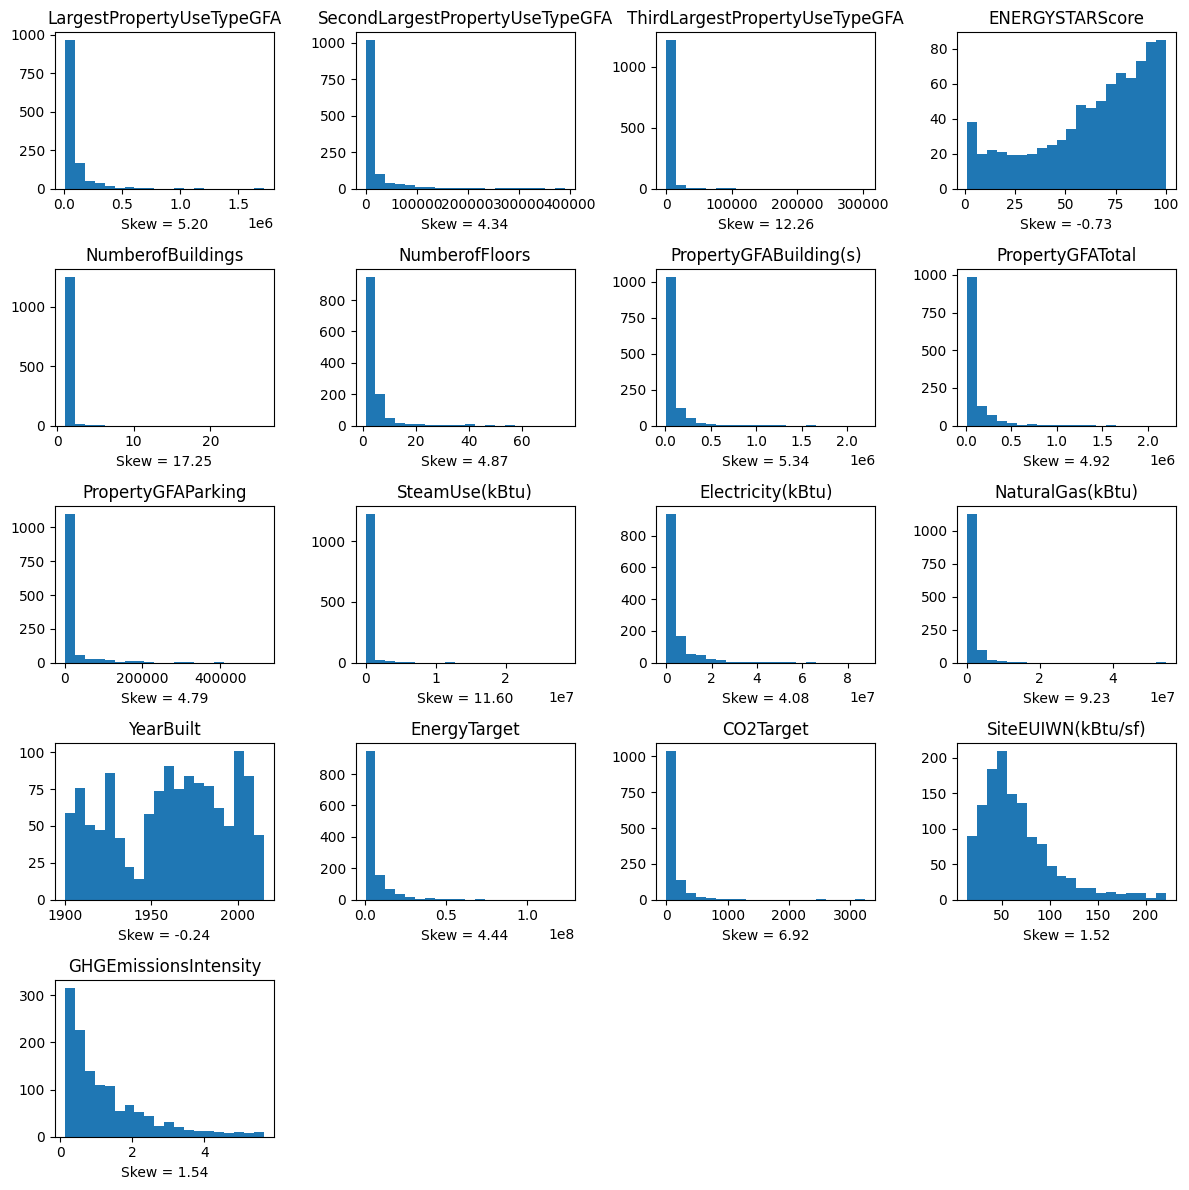

In [29]:
plt.figure(figsize=(12, 12))

for i, v in enumerate(num_cols + target_cols, 1):
    plt.subplot(5, 4, i)              # 5 lignes, 4 colonnes
    plt.hist(df[v].dropna(), bins=20) # distribution simple
    s = df[v].skew()                  # skewness
    plt.title(v)
    plt.xlabel(f"Skew = {s:.2f}")     # affiché sous le graphe

plt.tight_layout()
plt.show()

Pas très parlant on va log1p les variables avec un fort skew. 

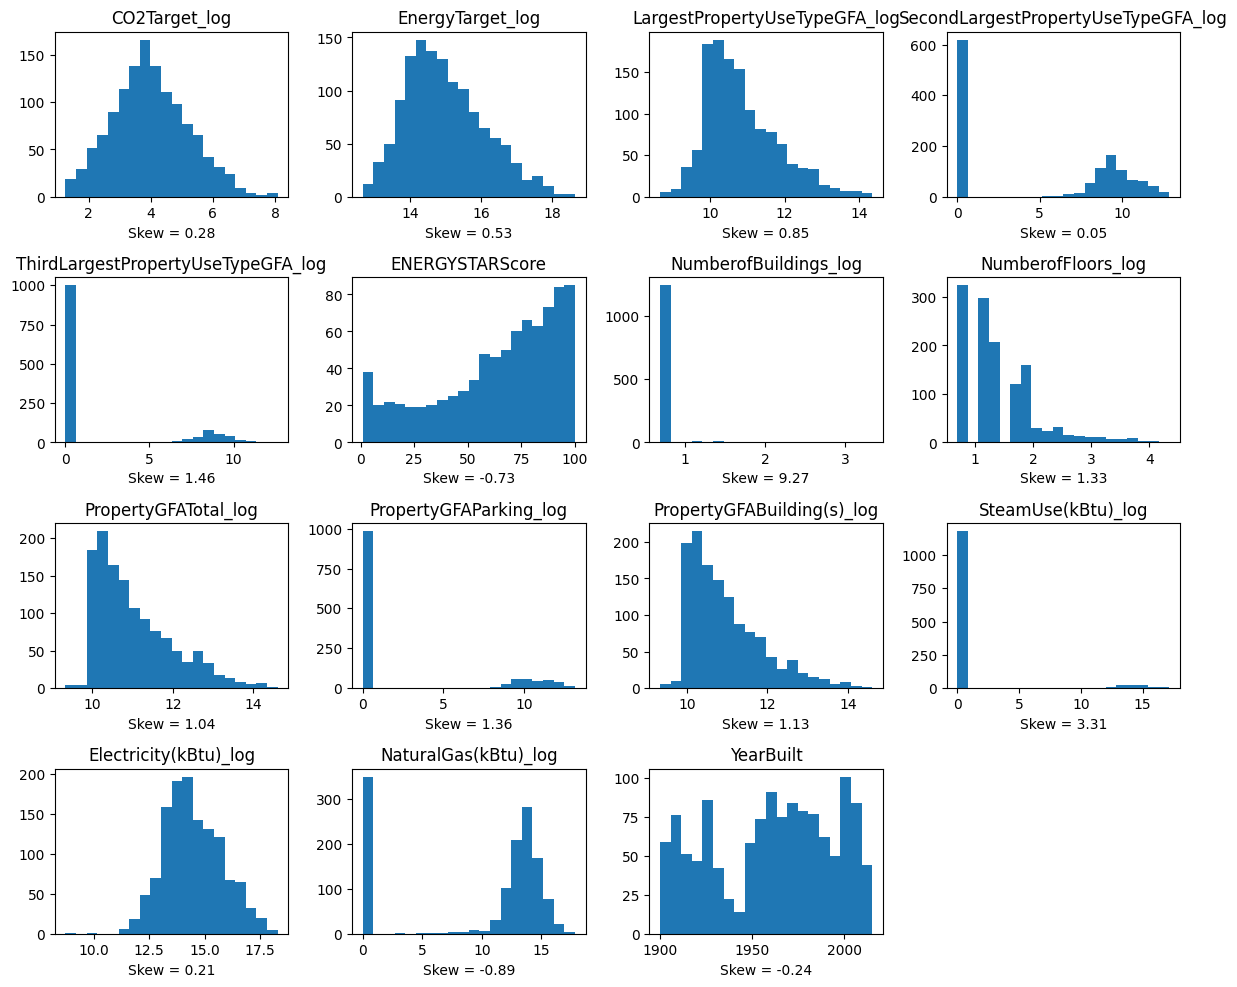

In [30]:
cols_to_log = [c for c in (num_cols + target_cols) if c not in ["ENERGYSTARScore", "YearBuilt","Latitude","Longitude"]]

for col in cols_to_log:
    df[f"{col}_log"] = np.log1p(df[col])

num_cols_plot = [
    "CO2Target_log",
    "EnergyTarget_log",
    "LargestPropertyUseTypeGFA_log",
    "SecondLargestPropertyUseTypeGFA_log",
    "ThirdLargestPropertyUseTypeGFA_log",
    "ENERGYSTARScore",          
    "NumberofBuildings_log",
    "NumberofFloors_log",
    "PropertyGFATotal_log",
    "PropertyGFAParking_log",
    "PropertyGFABuilding(s)_log",
    "SteamUse(kBtu)_log",
    "Electricity(kBtu)_log",
    "NaturalGas(kBtu)_log",
    "YearBuilt"
]

plt.figure(figsize=(12, 12))

for i, v in enumerate(num_cols_plot, 1):
    plt.subplot(5, 4, i)              # 5 lignes, 4 colonnes
    plt.hist(df[v].dropna(), bins=20) # distribution simple
    s = df[v].skew()                  # skewness
    plt.title(v)
    plt.xlabel(f"Skew = {s:.2f}")     # affiché sous le graphe

plt.tight_layout()
plt.show()

Comme attendu, les distributions logarithmiques sont plus simple à visualiser.  
On reste sur des distribution normale avec des skew bien plus réduits après transformation log1p.  
On voit à plusieurs reprises des grandes barres en 0 puis distribution normale sur la droite mais à chaque fois il s'agit de cas explicable :  
- gaz, steam pas utilisés la plupart du temps,  
- pas de parking la plupart du temps,  
- 1 seul bâtiment la plupart du temps  

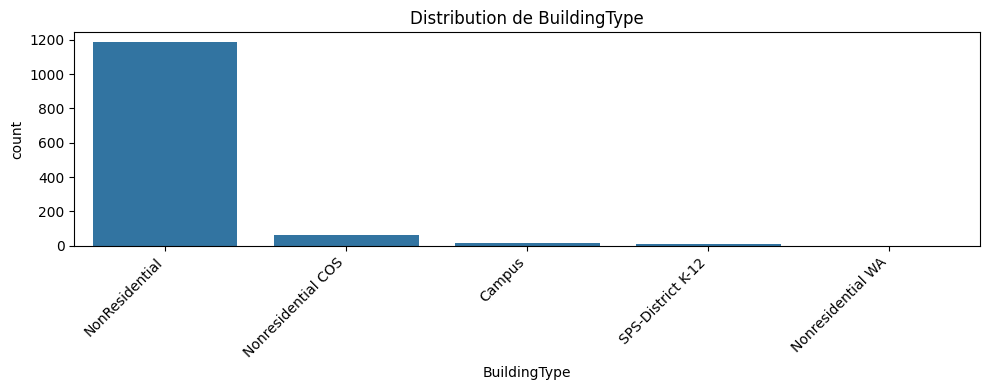

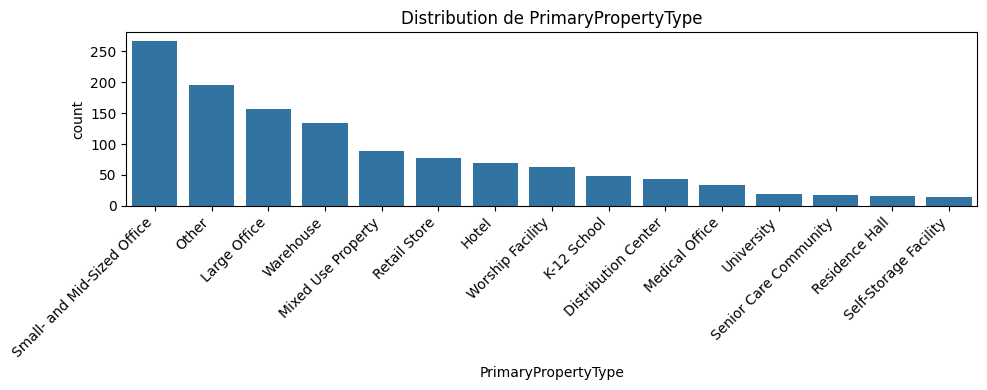

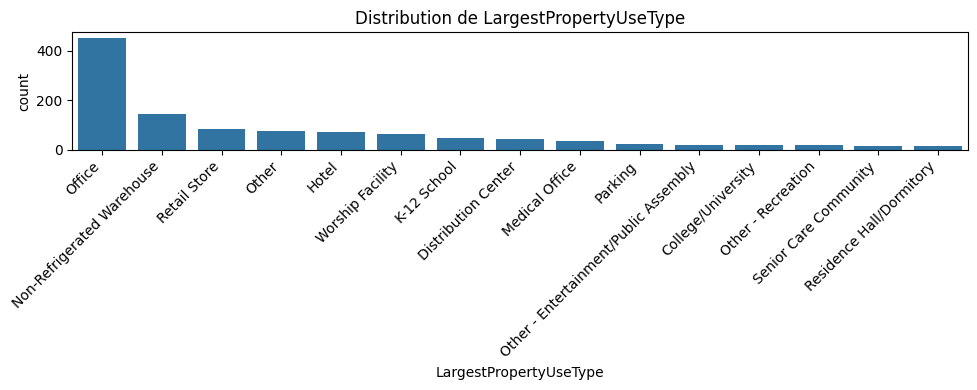

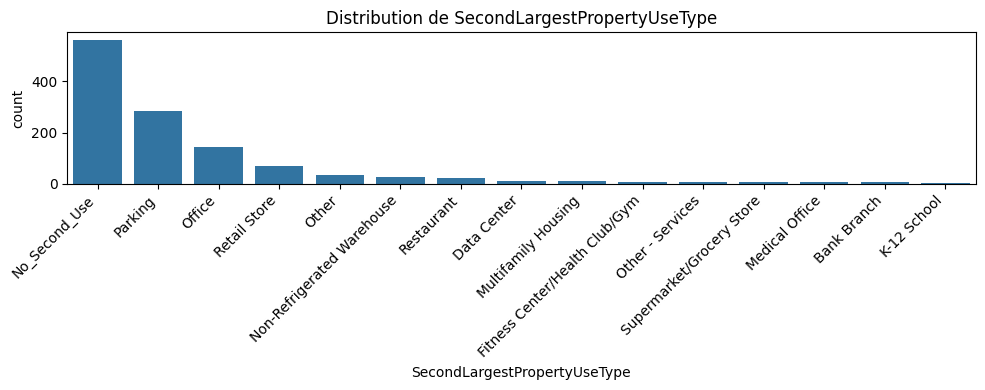

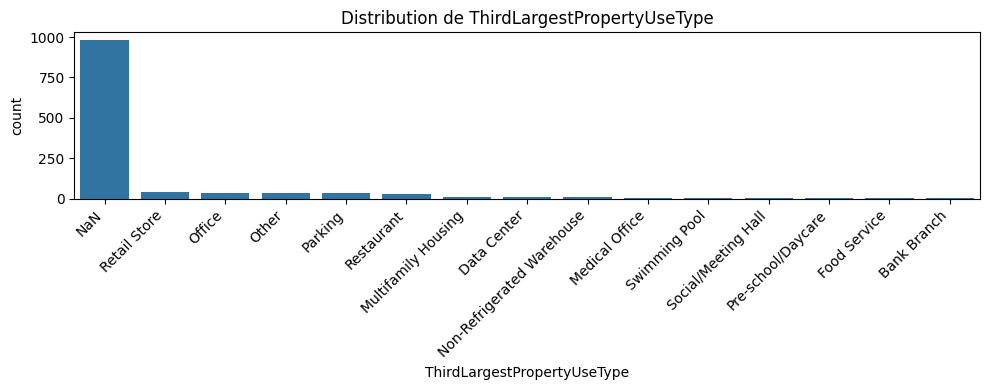

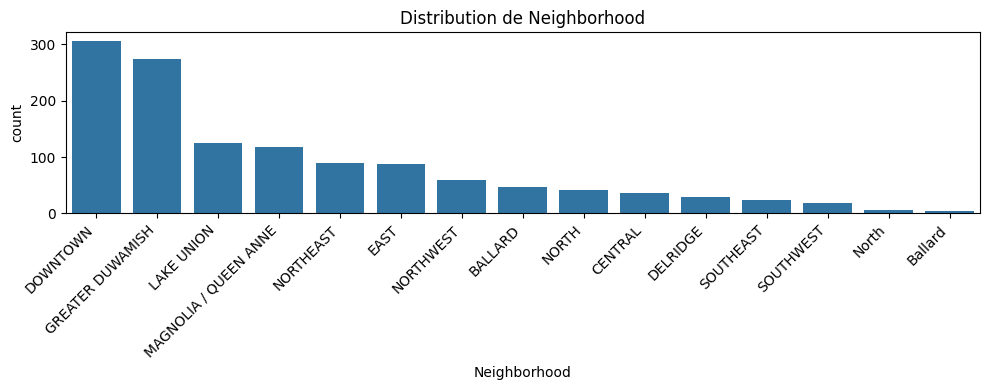

In [31]:
cat_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns


for col in cat_cols:
    plot_data = df[col].fillna("NaN").astype(str)
    order = plot_data.value_counts().index[:15]

    plt.figure(figsize=(10, 4))
    sns.countplot(x=plot_data, order=order)
    plt.title(f"Distribution de {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Ok rien de trop étonnant dans ces graphes, de plus on peut déjà voir qu'ils sont cohérents avec les features numériques analysées juste avant (second usage bâtiment non majoritaire)

### Analyses bivariées et correlation :

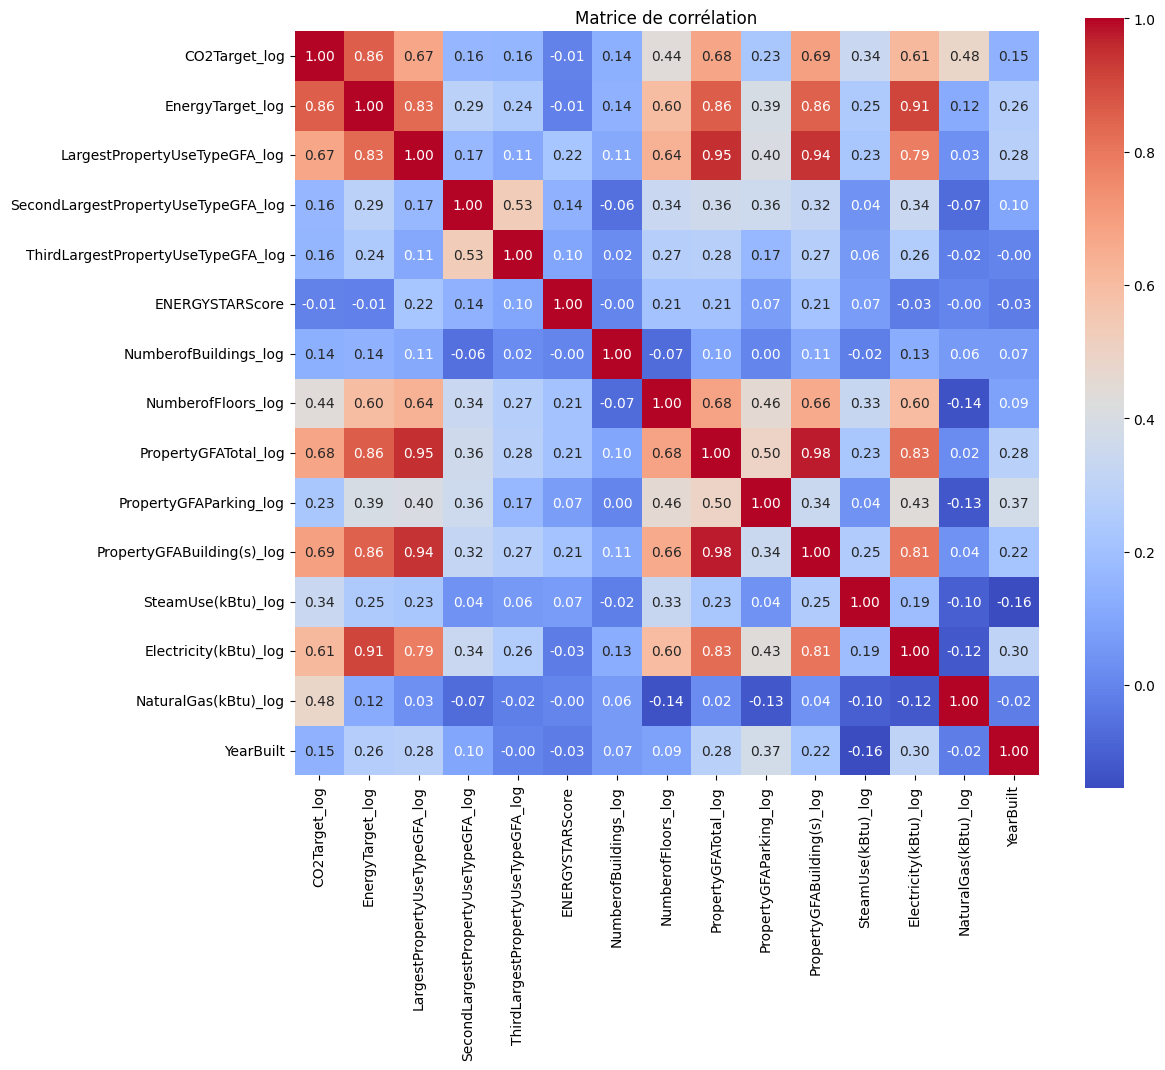

In [32]:
corr = df[(num_cols_plot)].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation")
plt.show()

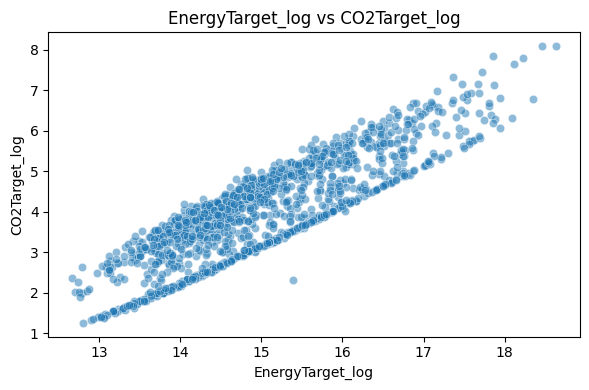

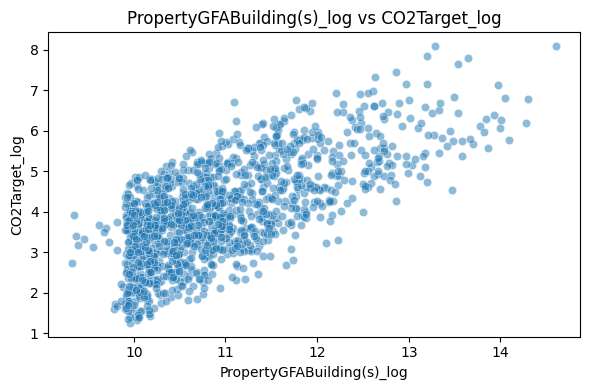

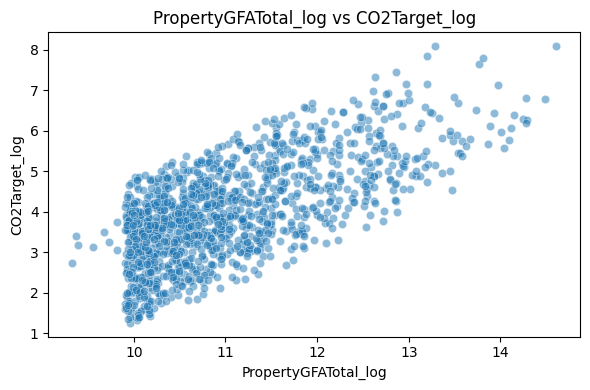

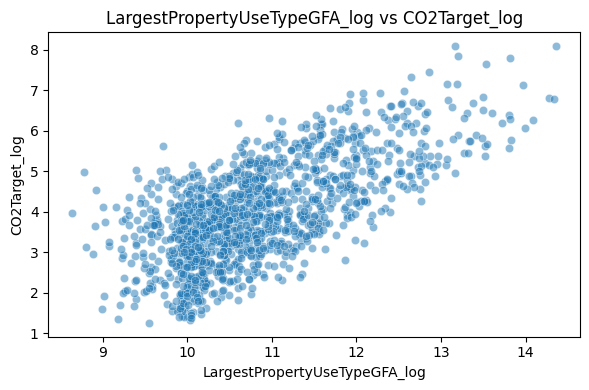

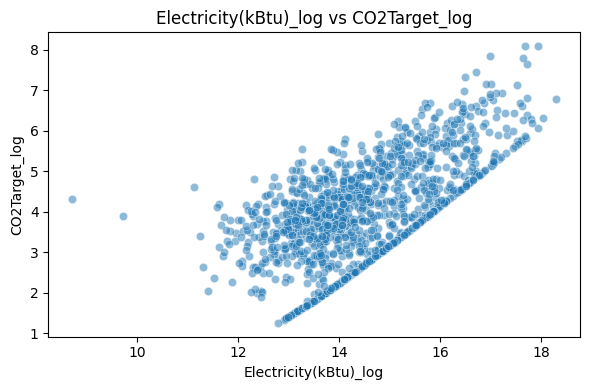

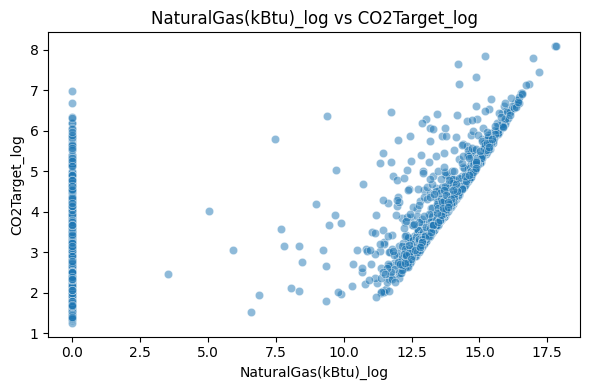

In [33]:
target = "CO2Target_log"

top_features = (corr[target].drop(index=target, errors="ignore").abs().sort_values(ascending=False).head(6).index)

for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y=target, alpha=0.5)
    plt.title(f"{col} vs {target}")
    plt.tight_layout()
    plt.show()

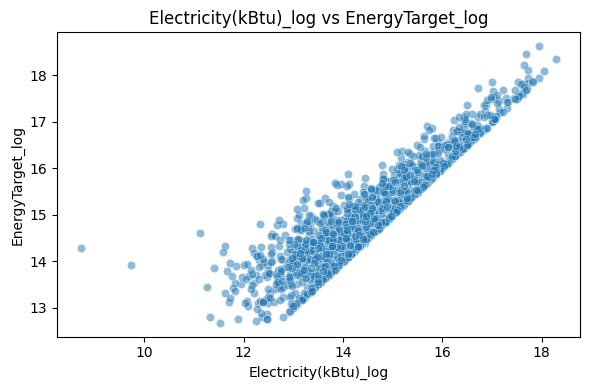

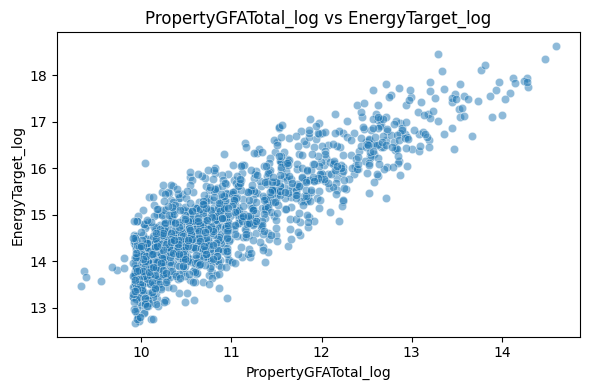

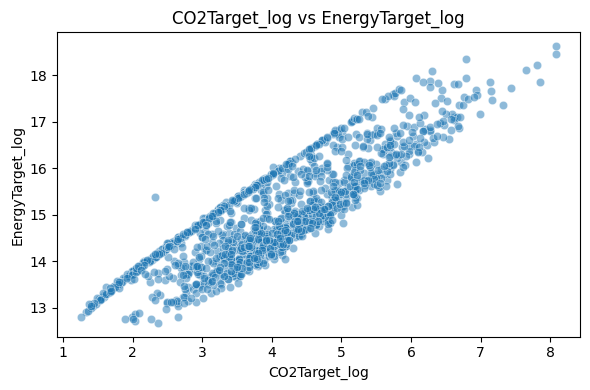

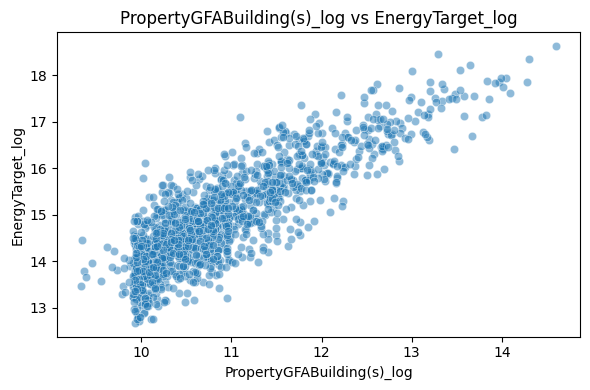

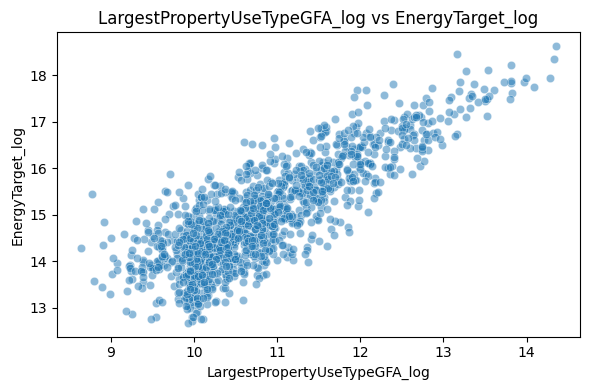

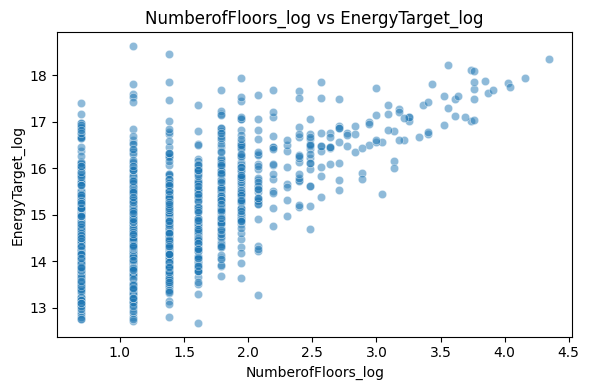

In [34]:
target = "EnergyTarget_log"

top_features = (corr[target].drop(index=target, errors="ignore").abs().sort_values(ascending=False).head(6).index)

for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y=target, alpha=0.5)
    plt.title(f"{col} vs {target}")
    plt.tight_layout()
    plt.show()

On voit une belle correlation quasi-linéaire entre les deux targets (pas illogique).  
Les correlations entre les deux targets et les features sont moins évidentes.

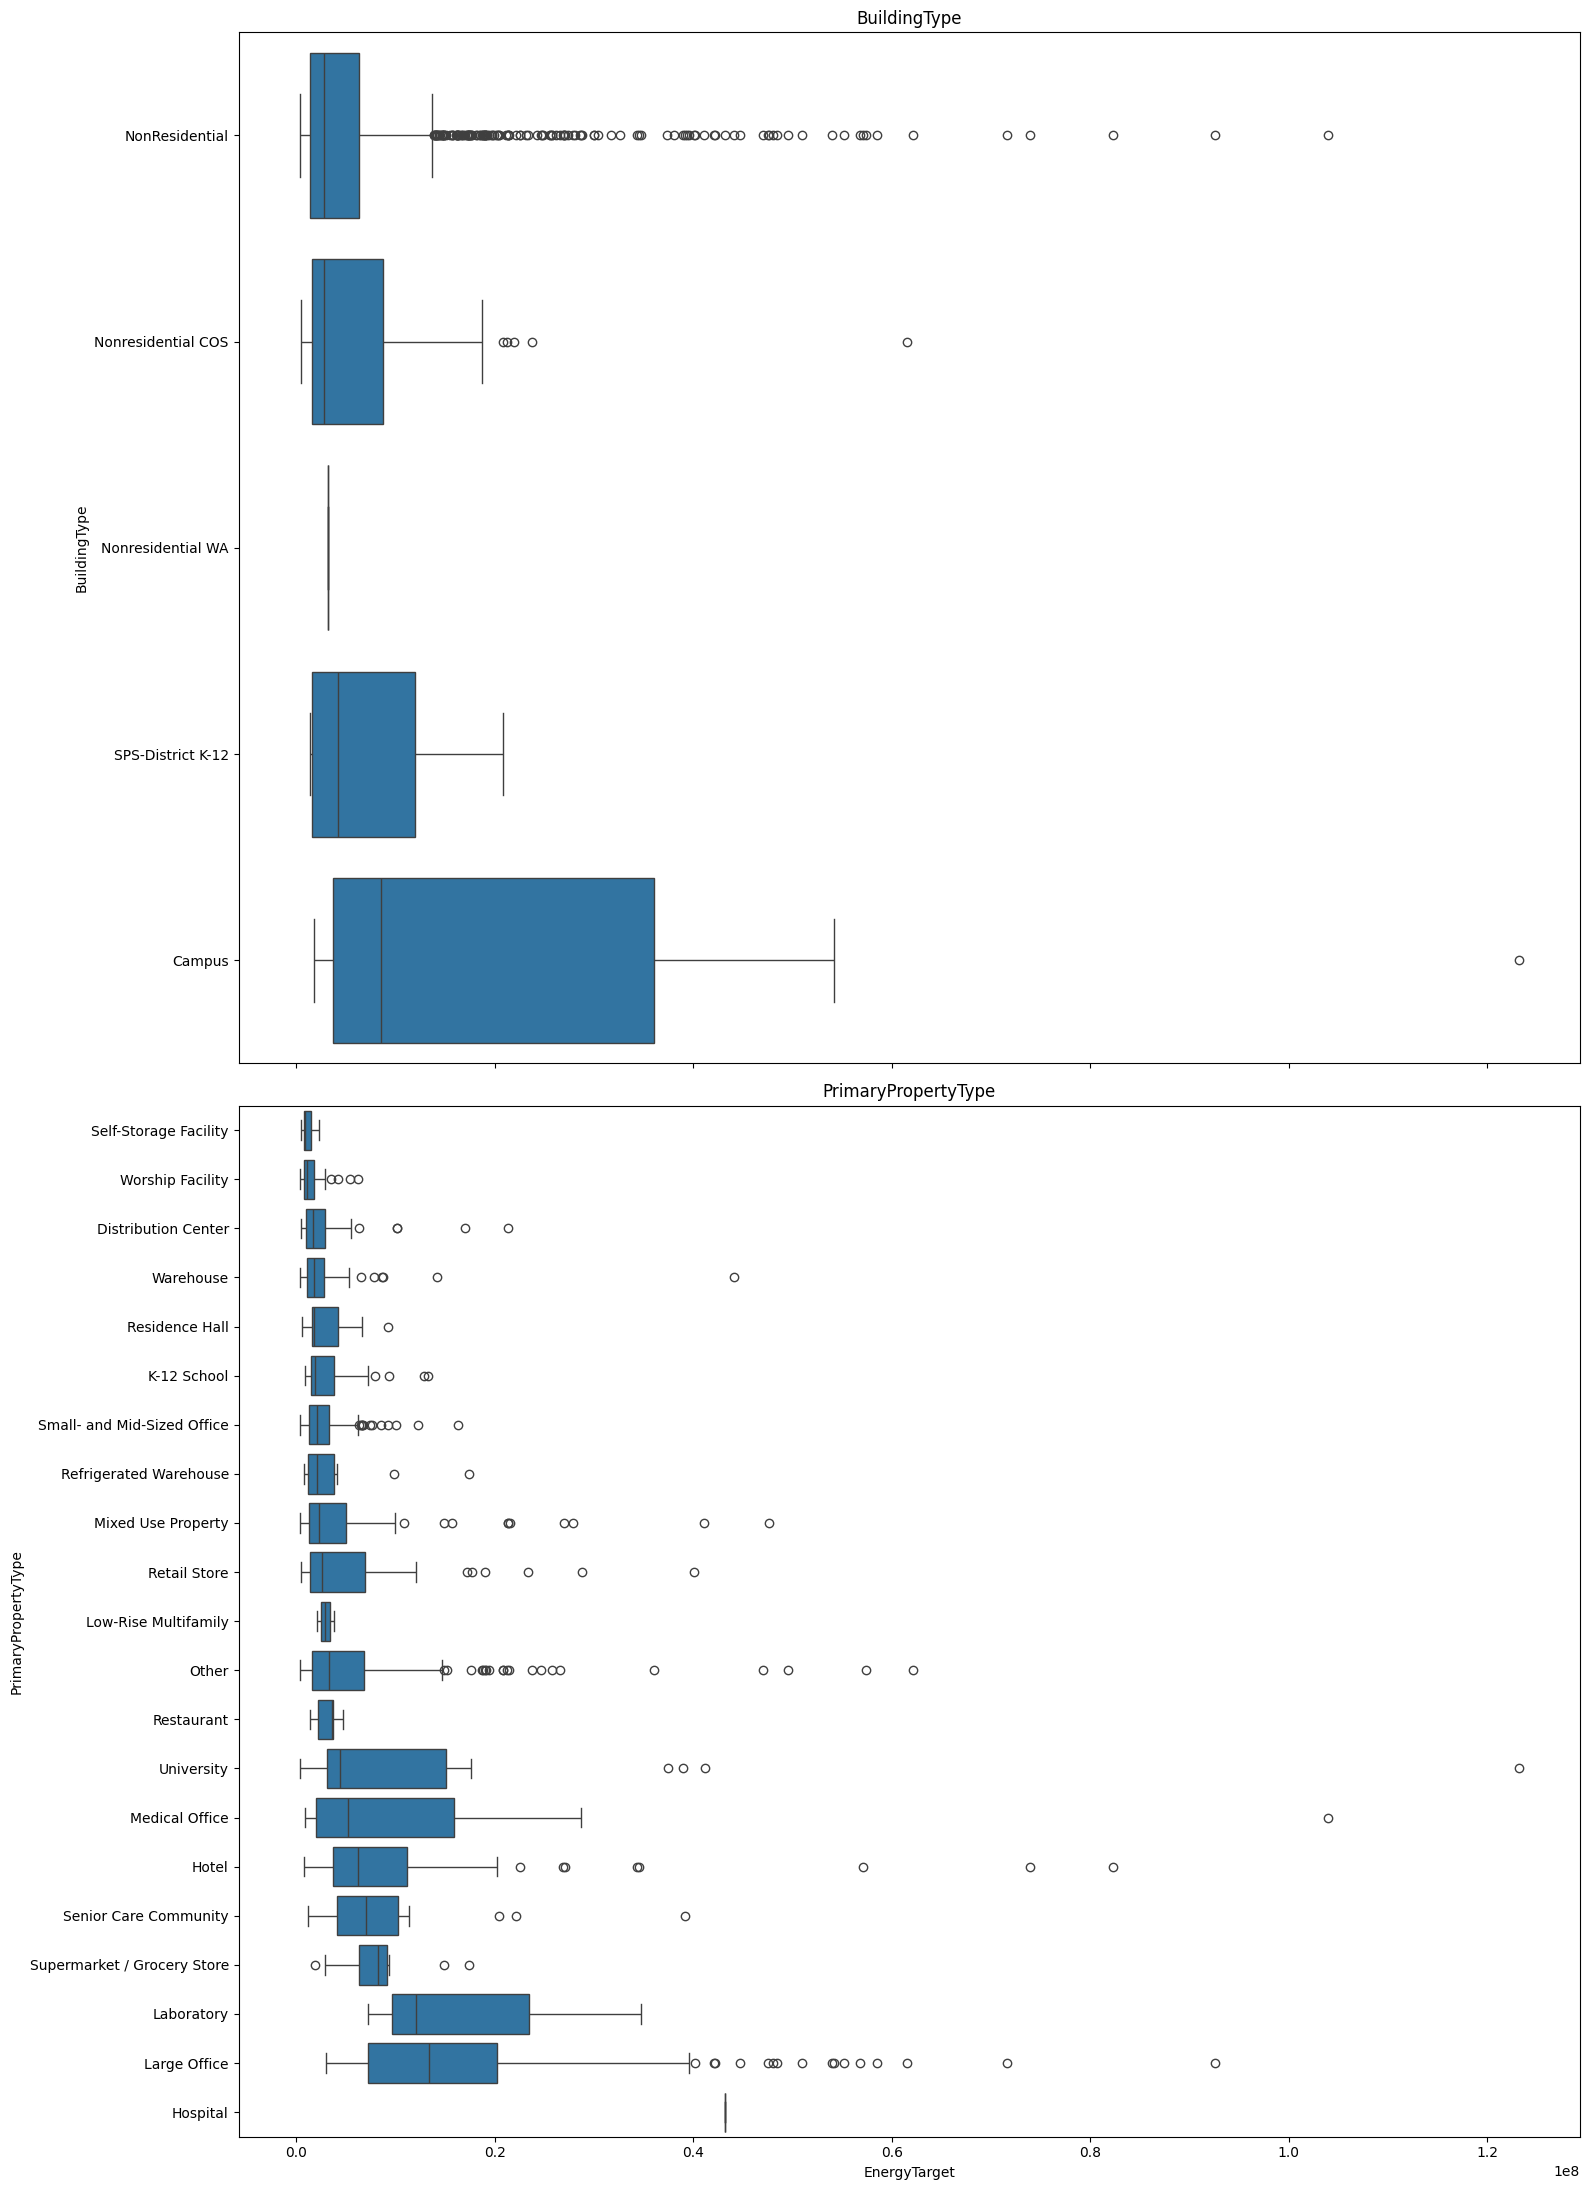

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(16, 22), sharex=True)

for ax, var in zip(axes, cat_cols):
    data = df[[var, "EnergyTarget"]].dropna()

    order = data.groupby(var)["EnergyTarget"].median().sort_values().index
    sns.boxplot(data=data, y=var, x="EnergyTarget", order=order, ax=ax)

    ax.set_title(var)

plt.tight_layout()
plt.show()

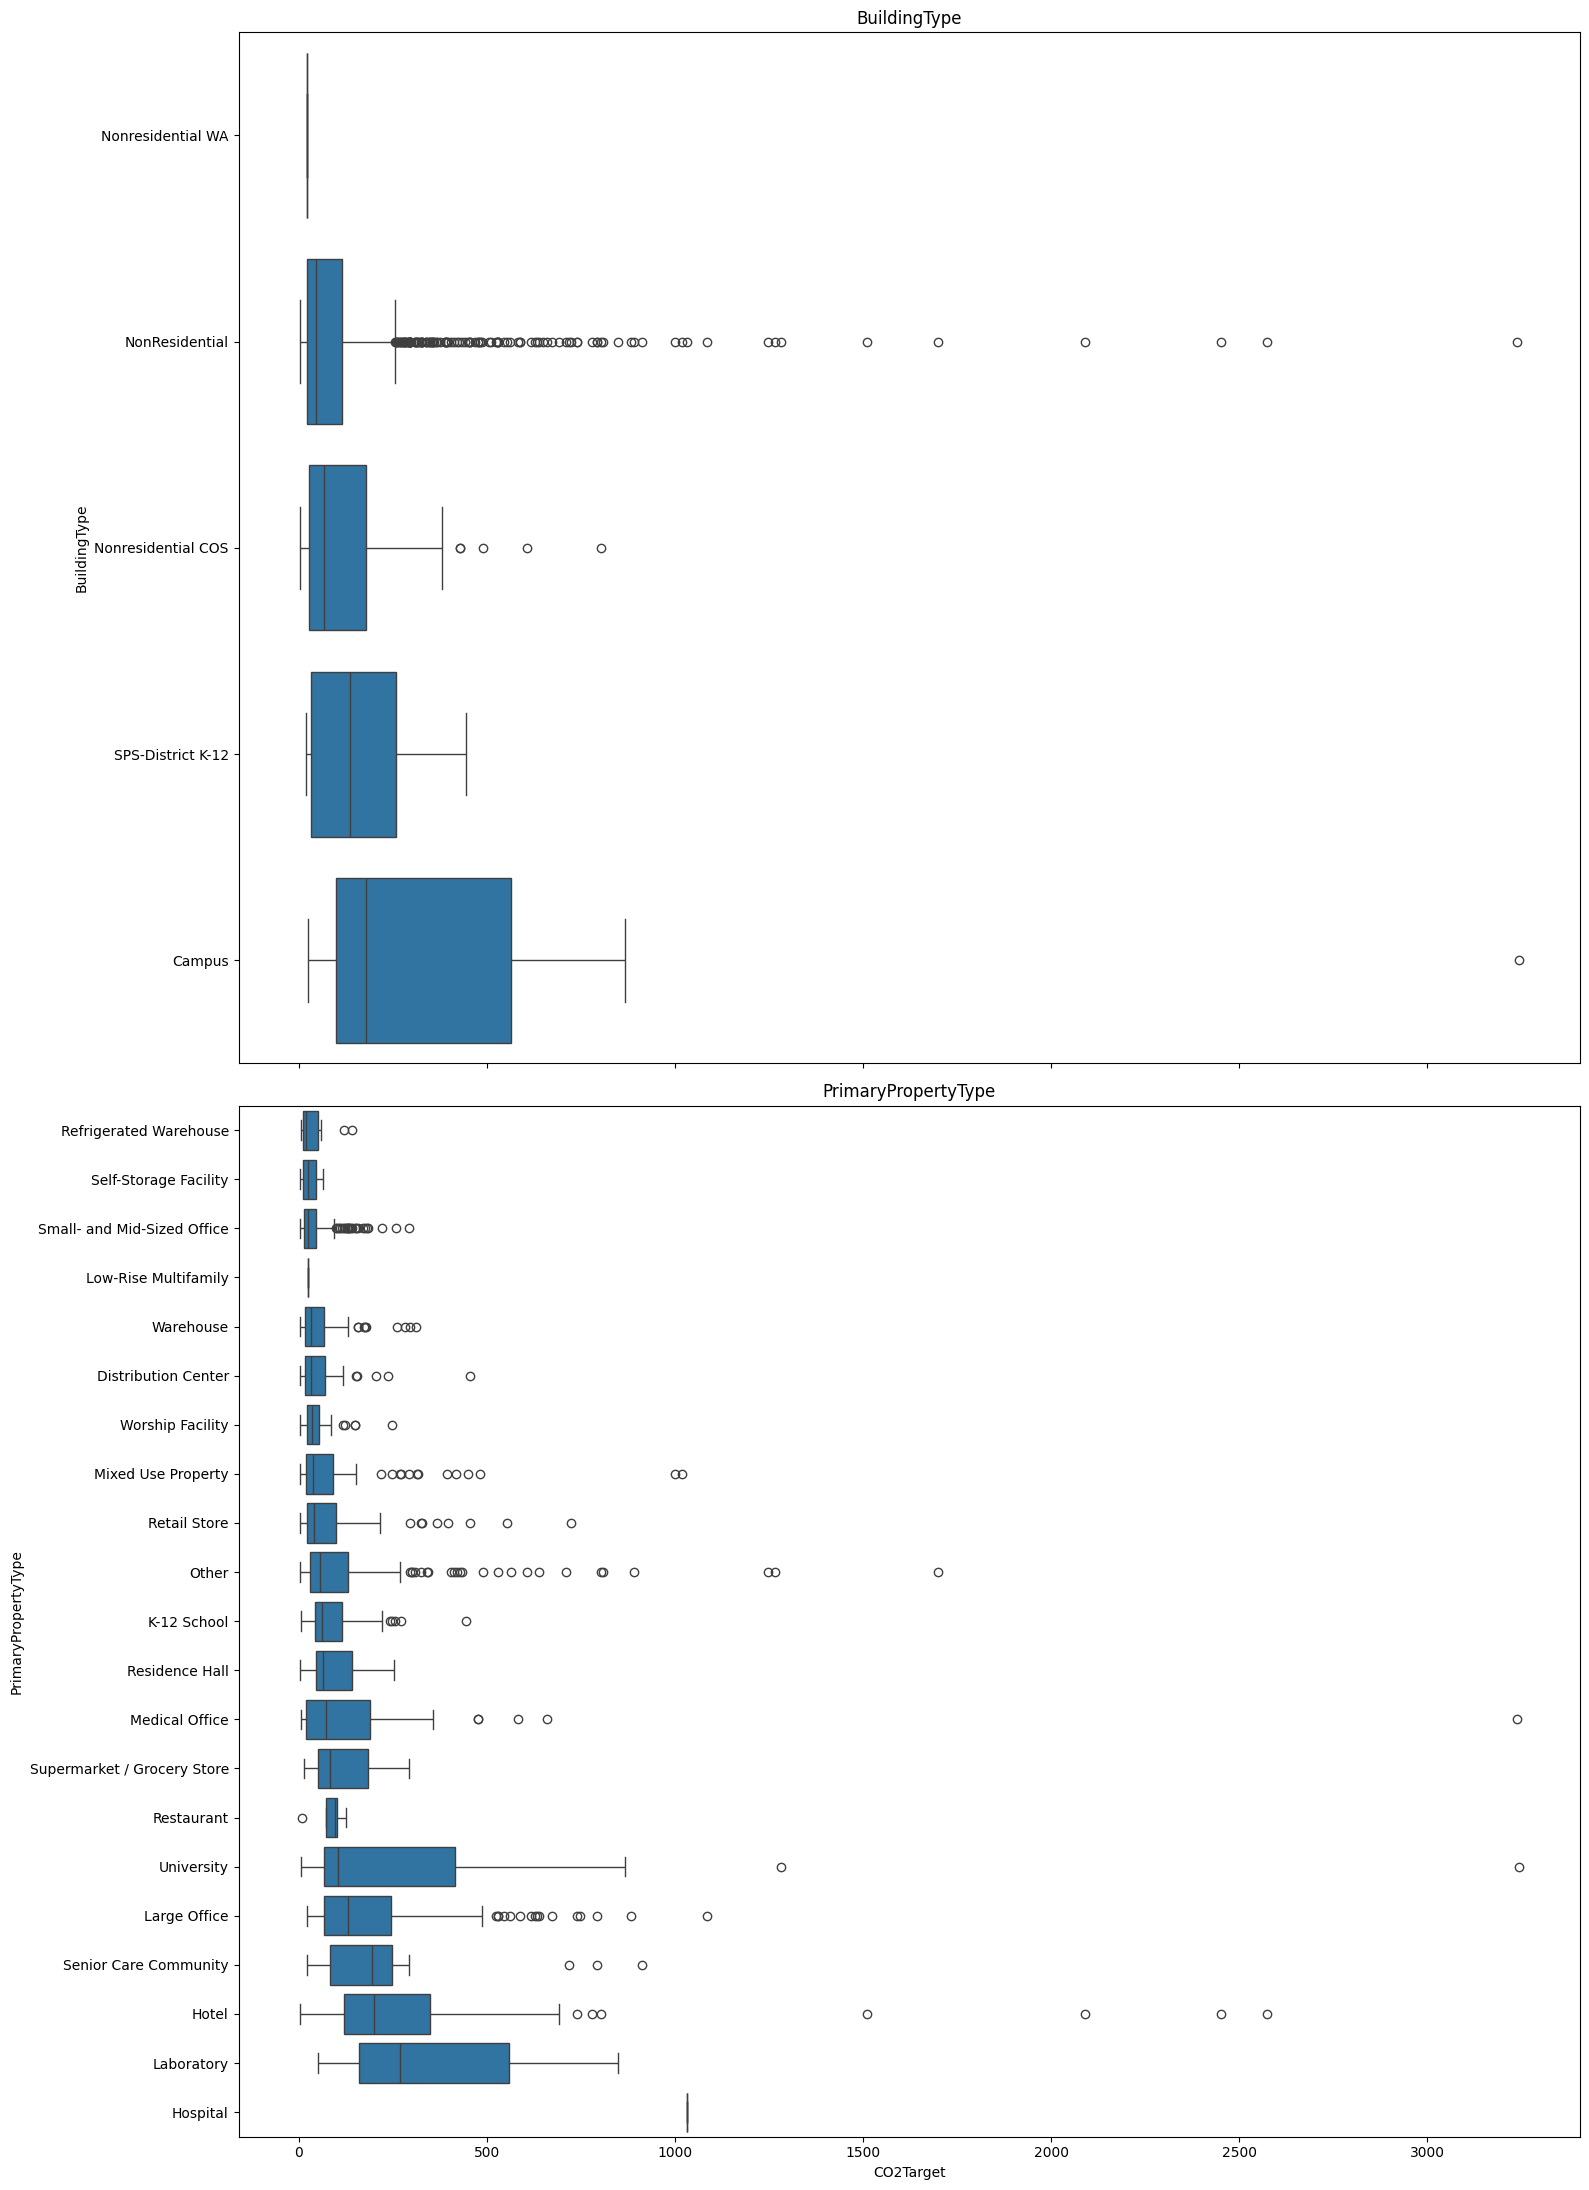

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(16, 22), sharex=True)

for ax, var in zip(axes, cat_cols):
    data = df[[var, "CO2Target"]].dropna()

    order = data.groupby(var)["CO2Target"].median().sort_values().index
    sns.boxplot(data=data, y=var, x="CO2Target", order=order, ax=ax)

    ax.set_title(var)

plt.tight_layout()
plt.show()

Rien de bien étonnant dans la visualisation de ces résultats, quelques valeurs "extrêmes" mais qui ne constitue pas pour autant des anomalies (déjà vérifié sur les targets). Les valeurs sont dans l'ensemble cohérentes et semblent pouvoir s'expliquer physiquement :  

 **Les hôpitaux consomment plus que les self-storage par exemple.**

## Bilan analyse exploratoire des donnees : 

Apres nettoyage et filtrages successifs, on obtient un dataset final de **1276 lignes** (contre 1668 apres filtre metier initial), soit environ **76.5%** des observations conservees sur ce perimetre.  

Les points cles :
- valeurs manquantes critiques traitees (drop/imputation),
- suppression des valeurs impossibles sur les cibles,
- reduction des outliers via percentiles sur les variables d'intensite,
- distributions stabilisees pour l'exploration via transformation log1p.

### Targets retenues pour la suite
- `EnergyTarget = SiteEnergyUseWN(kBtu)`
- `CO2Target = TotalGHGEmissions`

### Colonnes finales exportees (26)
Le dataset exporte conserve les 2 targets + 24 features (numeriques, categorielles et binaires) apres feature engineering et suppression des colonnes redondantes.



## Passons au feature engineering : 


### FEATURES PHYSIQUES

In [37]:
df.shape

(1276, 38)

In [38]:
floors = df["NumberofFloors"].replace(0, 1)
buildings = df["NumberofBuildings"].replace(0, 1)
gfa_total = df["PropertyGFATotal"].replace(0, 1)

df["GFA_per_floor"] = df["PropertyGFATotal"] / floors
df["BuildingGFARatio"] = df["PropertyGFABuilding(s)"] / gfa_total
df["GFA_per_building"] = df["PropertyGFABuilding(s)"] / buildings
df["Parking_per_building"] = df["PropertyGFAParking"] / buildings
# BuildingAge
REFERENCE_YEAR = 2016
df["BuildingAge"] = REFERENCE_YEAR - df["YearBuilt"]

# ParkingRatio
gfa_total = df["PropertyGFATotal"].replace(0, 1)
df["ParkingRatio"] = df["PropertyGFAParking"] / gfa_total

### USAGES

In [39]:
# Harmoniser la colonne avant création des indicateurs
df["SecondLargestPropertyUseType"] = df["SecondLargestPropertyUseType"].fillna("No_Second_Use")
df["ThirdLargestPropertyUseType"] = df["ThirdLargestPropertyUseType"].fillna("No_Third_Use")

df["SecondLargestPropertyUseTypeGFA"] = df["SecondLargestPropertyUseTypeGFA"].fillna(0)
df["ThirdLargestPropertyUseTypeGFA"] = df["ThirdLargestPropertyUseTypeGFA"].fillna(0)

gfa_total = df["PropertyGFATotal"].replace(0, 1)

# Ratio du 1er, 2e et 3e usage
df["LargestUseRatio"] = df["LargestPropertyUseTypeGFA"].fillna(0) / gfa_total
df["SecondUseRatio"] = df["SecondLargestPropertyUseTypeGFA"] / gfa_total
df["ThirdUseRatio"] = df["ThirdLargestPropertyUseTypeGFA"] / gfa_total

# Indicateur multi-usage
df["IsMixedUse"] = (df["SecondLargestPropertyUseType"] != "No_Second_Use").astype(int)

# Nombre d'usages renseignés
df["UseTypesCount"] = (
    1
    + (df["SecondLargestPropertyUseType"] != "No_Second_Use").astype(int)
    + (df["ThirdLargestPropertyUseType"] != "No_Third_Use").astype(int)
)


### ENERGIE

In [40]:
# Présence / absence de chaque source
df["UsesElectricity"] = ((df["Electricity(kBtu)"].fillna(0)) > 0).astype(int)
df["UsesGas"] = ((df["NaturalGas(kBtu)"].fillna(0)) > 0).astype(int)
df["UsesSteam"] = ((df["SteamUse(kBtu)"].fillna(0)) > 0).astype(int)

# Nombre de sources et indicateur multi-énergie
df["EnergySourcesCount"] = df[["UsesElectricity", "UsesGas", "UsesSteam"]].sum(axis=1)
df["IsMultiEnergy"] = (df["EnergySourcesCount"] > 1).astype(int)


### FEATURES CLASSIFICATION

In [41]:
#Classes d'âge
age_bins = [-np.inf, 1950, 1980, 2000, np.inf]
age_labels = [3, 2, 1, 0]
df["BuildingAgeCat"] = pd.cut(df["YearBuilt"],bins=age_bins,labels=age_labels,right=False)

#Classes de taille (quartiles)
df["SizeCategory"] = pd.qcut(df["PropertyGFATotal"],q=5,labels=[0, 1, 2, 3, 4],duplicates="drop")

#Converser l'information que l'ENERGYSTARScore était manquant
df["HasEnergyStarScore"] = df["ENERGYSTARScore"].notna().astype(int)

### RECAP' FEATURE ENGINEERING

In [42]:
#Aperçu des nouvelles features
new_features = [
    "GFA_per_floor",
    "BuildingGFARatio", 
    "GFA_per_building",
    "Parking_per_building",
    "BuildingAge",
    "ParkingRatio",
    "LargestUseRatio",
    "SecondUseRatio",
    "ThirdUseRatio",
    "IsMixedUse",
    "UseTypesCount",
    "UsesElectricity", 
    "UsesGas", 
    "UsesSteam", 
    "EnergySourcesCount",
    "BuildingAgeCat", 
    "SizeCategory",
    "HasEnergyStarScore"
]

df[new_features].head()

,GFA_per_floor,BuildingGFARatio,GFA_per_building,Parking_per_building,BuildingAge,ParkingRatio,LargestUseRatio,SecondUseRatio,ThirdUseRatio,IsMixedUse,UseTypesCount,UsesElectricity,UsesGas,UsesSteam,EnergySourcesCount,BuildingAgeCat,SizeCategory,HasEnergyStarScore
0,7369.500000,1.000000,88434.0,0.0,89,0.000000,1.000000,0.000000,0.000000,0,1,1,1,1,3,3,3,1
1,9415.090909,0.854547,88502.0,15064.0,20,0.145453,0.809918,0.145453,0.044629,1,3,1,1,0,2,1,3,1
2,23319.756098,0.794252,759392.0,196718.0,47,0.205748,0.791220,0.000000,0.000000,0,1,1,1,1,3,2,4,1
3,6132.000000,1.000000,61320.0,0.0,90,0.000000,1.000000,0.000000,0.000000,0,1,1,1,1,3,3,2,1
4,9754.444444,0.646885,113580.0,62000.0,36,0.353115,0.703070,0.387339,0.000000,1,3,1,1,0,2,1,4,1


**Liste finale des variables dans le dataset (avant suppression des colonnes redondantes) :**


In [43]:
target_cols = [
    "EnergyTarget",
    "CO2Target"
]

num_cols = [
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "ENERGYSTARScore",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "BuildingAge",
    "GFA_per_floor",
    "BuildingGFARatio",
    "GFA_per_building",
    "Parking_per_building",
    "ParkingRatio",
    "LargestUseRatio",
    "SecondUseRatio",
    "ThirdUseRatio",
]

bool_cols = [
    "HasEnergyStarScore",
    "UsesElectricity", 
    "UsesGas",
    "UsesSteam",
]

cat_cols = [
    "BuildingType",
    "PrimaryPropertyType",
    "Neighborhood",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType",
    "BuildingAgeCat",
    "SizeCategory"
    ]


# Colonnes à conserver (features + target)
cols_conservees = target_cols + num_cols + cat_cols + bool_cols 

# Filtrage du dataframe
df = df[cols_conservees].copy()

df.columns

Index(['EnergyTarget', 'CO2Target', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA',
       'ENERGYSTARScore', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFAParking', 'PropertyGFABuilding(s)', 'BuildingAge',
       'GFA_per_floor', 'BuildingGFARatio', 'GFA_per_building',
       'Parking_per_building', 'ParkingRatio', 'LargestUseRatio',
       'SecondUseRatio', 'ThirdUseRatio', 'BuildingType',
       'PrimaryPropertyType', 'Neighborhood', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType', 'BuildingAgeCat', 'SizeCategory',
       'HasEnergyStarScore', 'UsesElectricity', 'UsesGas', 'UsesSteam'],
      dtype='str')

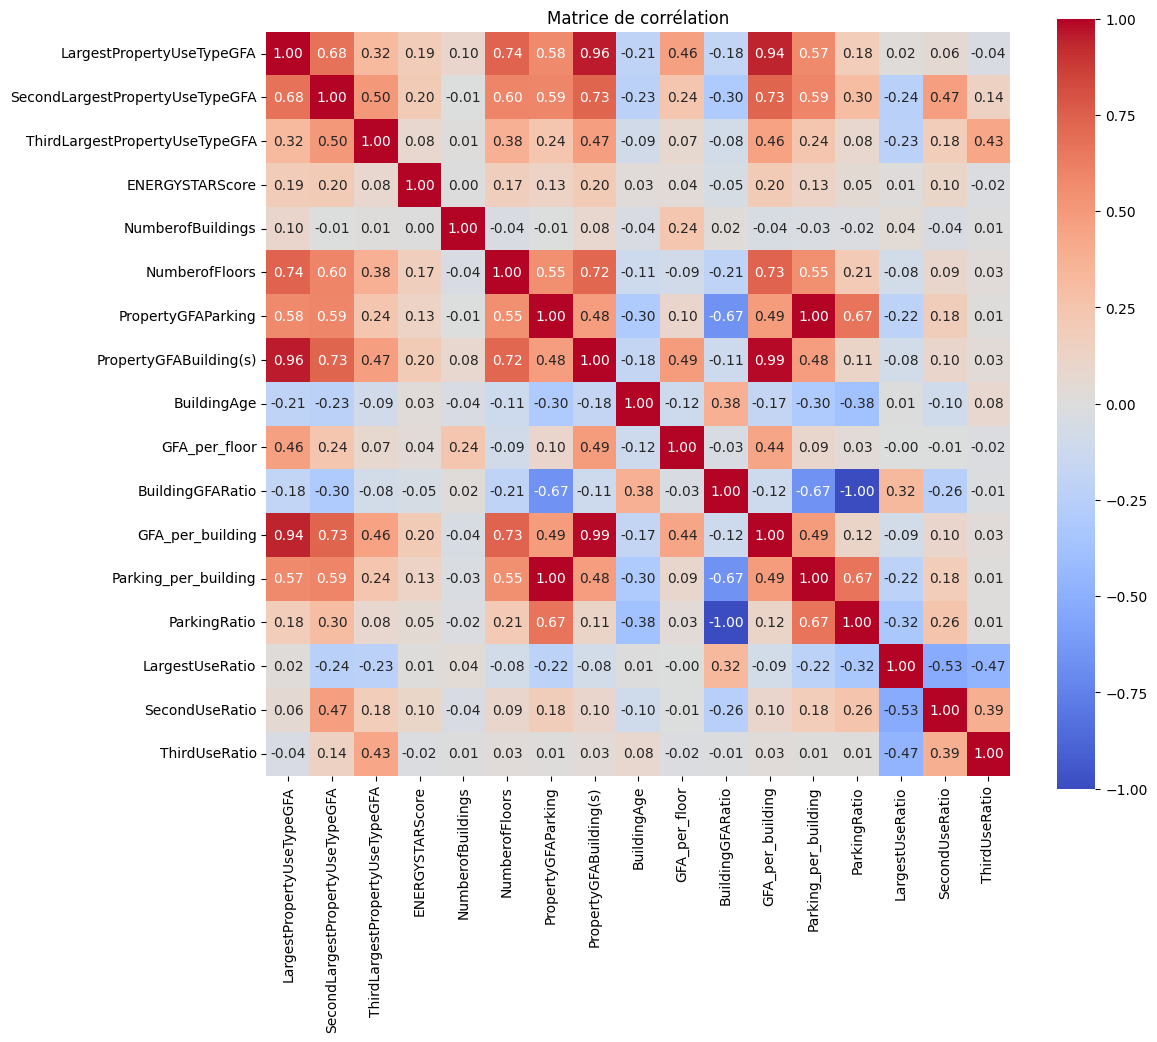

In [44]:
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation")
plt.show()

On supprime `PropertyGFABuilding(s)`, `GFA_per_building`, `Parking_per_building` et `ParkingRatio` car fortement correlees avec d'autres variables.


In [45]:
df = df.drop(columns=["PropertyGFABuilding(s)", "GFA_per_building","Parking_per_building","ParkingRatio"])

df.shape

(1276, 26)

Liste finale des variables par categorie presentes dans le dataset (version exportee) :
- 2 targets (`EnergyTarget`, `CO2Target`)
- variables numeriques
- variables categorielles
- variables binaires derivees


In [46]:
target_cols = [
    "EnergyTarget",
    "CO2Target"
]

num_cols = [
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "ENERGYSTARScore",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFAParking",
    "BuildingAge",
    "GFA_per_building",
    "BuildingGFARatio",
    "ParkingRatio",
    "LargestUseRatio",
    "SecondUseRatio",
    "ThirdUseRatio",
]

bool_cols = [
    "HasEnergyStarScore",
    "UsesElectricity", 
    "UsesGas",
    "UsesSteam",
]

cat_cols = [
    "BuildingType",
    "PrimaryPropertyType",
    "Neighborhood",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType",
    "BuildingAgeCat",
    "SizeCategory"
    ]

In [47]:
print(df.shape)
print(df.columns.tolist())

(1276, 26)
['EnergyTarget', 'CO2Target', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'BuildingAge', 'GFA_per_floor', 'BuildingGFARatio', 'LargestUseRatio', 'SecondUseRatio', 'ThirdUseRatio', 'BuildingType', 'PrimaryPropertyType', 'Neighborhood', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'BuildingAgeCat', 'SizeCategory', 'HasEnergyStarScore', 'UsesElectricity', 'UsesGas', 'UsesSteam']


On exporte le dataframe final en `.csv` pour l'utiliser dans le notebook 2 : `PROJET 3_Notebook_Modelisation.ipynb`.


In [48]:
df.to_csv("df_modele.csv", index=False)